<a href="https://colab.research.google.com/github/igorznog/FarmTech_Solutions/blob/main/World_happiness_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#World happiness Report



O objetivo deste projeto é analisar o 'World Happiness Report 2019' para entender os fatores que contribuem para a felicidade em diferentes países. Através da exploração dos dados, buscaremos identificar:

*   **Países Mais e Menos Felizes:** Quais são os países com as maiores e menores pontuações de felicidade.
*   **Fatores Determinantes:** A influência de variáveis como PIB per capita, suporte social, expectativa de vida saudável, liberdade, generosidade e percepção de corrupção na pontuação de felicidade.
*   **Correlações:** Quais variáveis têm a maior correlação com a pontuação de felicidade.
*   **Anomalias:** Identificar possíveis outliers ou padrões incomuns nos dados que possam indicar situações específicas em certos países.

Este entendimento nos permitirá obter insights sobre o bem-estar global e os elementos socioeconômicos que o impulsionam.

## Importar as biblíotecas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importar dataset


In [ ]:
df = pd.read_csv("/content/2019.csv",sep ="," ,encoding ='utf-8') #utf-8, não deixa as palavras com acento quebrarem

##Análise inicial

In [ ]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


Visualização das 5 primeiras linhas do dataset

In [ ]:
df.tail()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


Visualização das 5 últimas linhas do dataset

In [ ]:
df.shape

(156, 9)

O dataset possui 156 linhas e 9 coluna

##Limpeza de dados

In [ ]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


No df não existe valores nulos

Caso tivesse:

In [ ]:
#df.dropna()(para poucos valores nulos. Removendo-os)

In [ ]:
#df.fillna(0)(substitue os valores por 0)

In [ ]:
#df.fillna(5)(substitue os valores por 5)

In [ ]:
#df.fillna(df.mean())(substitue os valores pela média)

In [ ]:
#df.fillna(df.median())(substitue os valores pela mediana)

In [ ]:
#df['coluna'].fillna(0) (substitue apenas a coluna desejada por 0)

In [ ]:
df.dtypes

,0
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


In [ ]:
#df['coluna'].astype('tipo certo') (Utilizado para trocar o tipo do dado )

##Análise exploratória de dados (EDA)

In [ ]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


* **Integridade dos Dados:** O dataset está completo com **156 países** e não apresenta valores ausentes.
* **Equilíbrio na Felicidade:** A pontuação média de felicidade é **5,40**. Como a média e a mediana são quase iguais, a distribuição é equilibrada (sem muitos países "extremos" puxando a nota para cima ou para baixo).
* **Desigualdade Social e Econômica:** Existe um abismo entre as nações. Enquanto alguns países têm nota **0** em PIB e Apoio Social, outros chegam a **1,6**. Esses dois fatores são os que mais variam.
* **Saúde é Prioridade:** Países no topo do ranking (os 25% mais felizes) têm expectativa de vida saudável acima de **0,88**, enquanto os da base ficam abaixo de **0,54**.
* **Corrupção Institucional:** A percepção de corrupção é baixa na maioria esmagadora dos países (mediana de apenas **0,08**), indicando que poucos países gozam de altíssima confiança em suas instituições.

##Top 5 países mais felizes

In [ ]:
top_5_felizes= df.nlargest(5,'Score')
display(top_5_felizes)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


Top 5 países mais felizes são :
- Finland
- Denmark
- Norway
- Iceland
- Netherlands

Outra maneira :

In [ ]:
df.sort_values(by='Score',ascending=False).head() # Ascending igual a false ( descrescente )

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


##Países com a pior saúde

In [ ]:
top_5_piores_saudes=df.nsmallest(5,'Healthy life expectancy')
display(top_5_piores_saudes)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
134,135,Swaziland,4.212,0.811,1.149,0.000,0.313,0.074,0.135
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
143,144,Lesotho,3.802,0.489,1.169,0.168,0.359,0.107,0.093
131,132,Chad,4.350,0.350,0.766,0.192,0.174,0.198,0.078
98,99,Ivory Coast,4.944,0.569,0.808,0.232,0.352,0.154,0.090


Top 5 países que possuem a pior saúde:
- Swaziland
- Central African Republic
- Lesotho
- Chad
- Ivory Coast

O país que possui a pior saúde segundo o df, está com o valor igual a zero (outliers). Portanto, vale confirmar se esse valor condiz com a realidade, e caso seja necessário, tratar esse dado.

In [ ]:
top_5_corruptos=df.nlargest(5,'Perceptions of corruption')
display(top_5_corruptos)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
33,34,Singapore,6.262,1.572,1.463,1.141,0.556,0.271,0.453
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380


Top 5 países mais corruptos:
- Singapore
- Rwanda
- Denmark
- Finland
- New Zealand

Mesmo países com score alto, possuem um nível surpreendente de corrupção, como por exemplo, a Finland, que está entre o Top 5 países com score mais alto.

##Matriz de correlação

In [ ]:
correlacao = df.corr(numeric_only=True)
display(correlacao['Score'].sort_values(ascending=False))

,Score
Score,1.000000
GDP per capita,0.793883
Healthy life expectancy,0.779883
Social support,0.777058
Freedom to make life choices,0.566742
Perceptions of corruption,0.385613
Generosity,0.075824
Overall rank,-0.989096


Nível de importância de cada variável para o calculo do score.
Notamos que, GDP per capita e Healthy life expectancy são as de mais peso. Enquanto, Generosity não possui tanta importância.

##Detecção de outliers (dados fora do padrão)

In [ ]:
Q1 = df['Score'].quantile(0.25)
Q3 = df['Score'].quantile(0.75)
IQR = Q3 - Q1

#Definindo limites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

#Filtrando países que são "outliers" de felicidade
outliers_felicidade = df[(df['Score'] < limite_inferior) | (df['Score'] > limite_superior)]
print(outliers_felicidade)

Empty DataFrame
Columns: [Overall rank, Country or region, Score, GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption]
Index: []


Não foi encontrado nenhum outlier.


# Visualização dos dados





##Heatmap

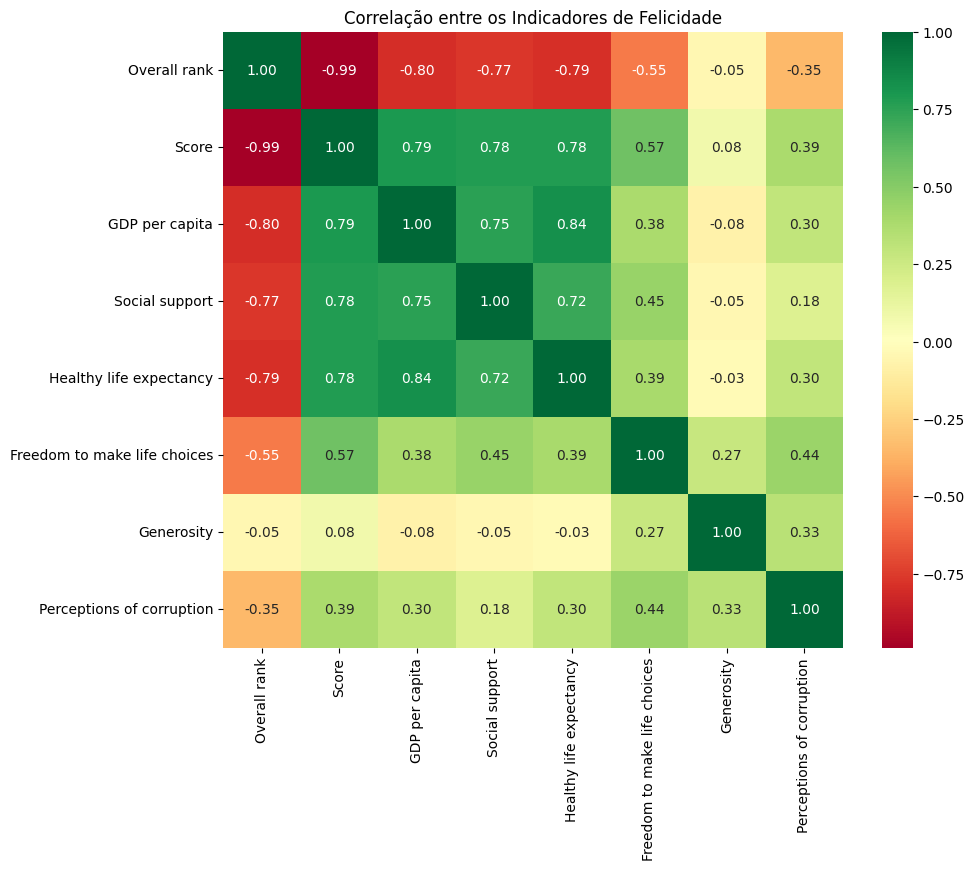

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlação entre os Indicadores de Felicidade')
plt.show()

##Histograma

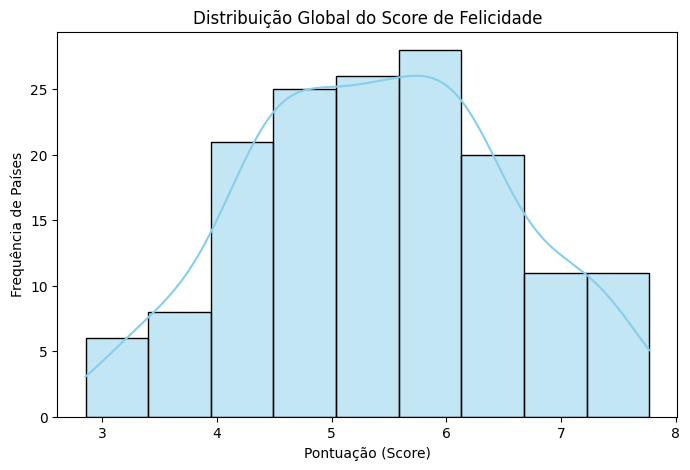

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Score'], kde=True, color='skyblue')
plt.title('Distribuição Global do Score de Felicidade')
plt.xlabel('Pontuação (Score)')
plt.ylabel('Frequência de Países')
plt.show()

##Gráfico de dispersão(Scatter plot)

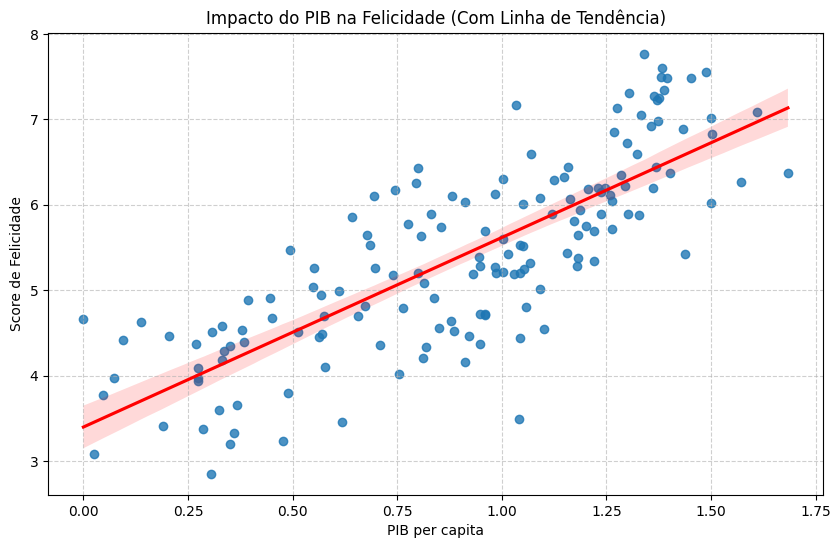

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDP per capita', y='Score', scatter_kws={'alpha':0.8}, line_kws={'color':'red'})
plt.title('Impacto do PIB na Felicidade (Com Linha de Tendência)')
plt.xlabel('PIB per capita')
plt.ylabel('Score de Felicidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##Gráfico de barras

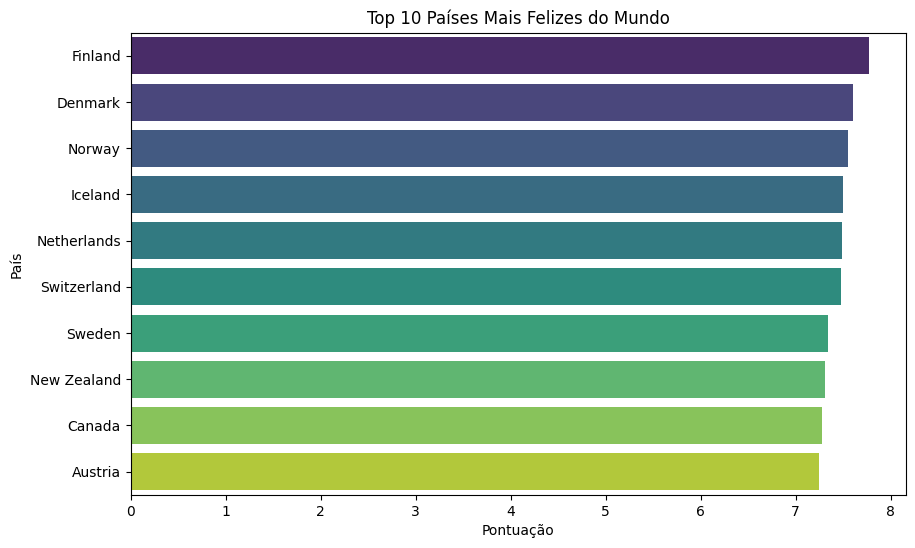

In [ ]:
plt.figure(figsize=(10, 6))
top_10 = df.nlargest(10, 'Score')
sns.barplot(data=top_10, x='Score', y='Country or region', palette='viridis', hue= 'Country or region')
plt.title('Top 10 Países Mais Felizes do Mundo')
plt.xlabel('Pontuação')
plt.ylabel('País')
plt.show()

##Conclusão das análises



A análise do 'World Happiness Report 2019' revelou insights importantes sobre os fatores que influenciam a felicidade global. Observamos que o dataset está limpo e completo, sem valores nulos, o que garante a robustez das análises.

### Principais Destaques:

*   **Países Mais Felizes:** Países como Finlândia, Dinamarca e Noruega consistentemente ocupam o topo do ranking, destacando a importância de fatores como **PIB per capita** e **suporte social** em suas pontuações elevadas.
*   **Fatores Determinantes:** A **matriz de correlação** confirmou que o **PIB per capita** e a **expectativa de vida saudável** são os indicadores com maior correlação positiva com a pontuação de felicidade. Isso sugere que o bem-estar econômico e a saúde são pilares fundamentais para a felicidade percebida.
*   **Impacto da Corrupção:** Embora países nórdicos estejam entre os mais felizes, a percepção de corrupção em alguns deles, como a Finlândia e a Dinamarca, ainda é notável, mostrando que mesmo em nações com altos níveis de bem-estar, a corrupção é uma preocupação, mas não impede seu score alto.
*   **Saúde e Qualidade de Vida:** Os países com as piores expectativas de vida saudável apontam para desafios significativos em regiões como a África Central, onde a saúde pública e as condições de vida são críticas. Foi identificado um outlier com valor zero, o que sugere a necessidade de uma investigação mais aprofundada ou tratamento de dados para essa variável.
*   **Ausência de Outliers Extremos:** A análise de outliers na pontuação de felicidade (`Score`) não identificou países com pontuações extremamente fora do padrão, indicando uma distribuição relativamente contínua de felicidade entre as nações estudadas.
*   **Distribuição da Felicidade:** O **histograma** da pontuação de felicidade mostrou uma distribuição equilibrada, com a maioria dos países concentrada em torno da média, sem picos acentuados ou caudas muito longas, reforçando a ideia de que não há muitos casos extremos de felicidade ou infelicidade.
*   **Visualização e Correlações:** O **heatmap** e o **gráfico de dispersão** do PIB per capita versus Score reforçam visualmente a forte correlação entre esses fatores, enquanto outras variáveis como generosidade mostraram uma menor influência, conforme indicado pela correlação.

Em resumo, o estudo do 'World Happiness Report 2019' sublinha a complexidade da felicidade e a interconexão de fatores socioeconômicos e de saúde. Políticas que promovem o desenvolvimento econômico, suporte social robusto, acesso à saúde de qualidade e liberdade são essenciais para elevar o bem-estar da população global. A análise dos dados permite uma compreensão mais profunda das prioridades para a melhoria da qualidade de vida em diferentes contextos globais.